# filename-sanitiser

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/filename-sanitiser/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/filename-sanitiser/demo.ipynb)

**`sanitise(name) -> str` is the wrong shape, and not because of which characters are on the deny-list.**

A sanitiser is a *projection*: it maps a large set of source names onto the smaller set of names a target filesystem accepts. Projections onto smaller sets collide - that is what the word means. The only question is whether the function tells you, and a function returning `str` structurally cannot: a collision is a fact about a **pair** of names, and it has one name in scope.

### What this notebook shows

1. Four distinct names, one file, four successful writes
2. Every source name lands in exactly one of three buckets - and the dangerous bucket is not the one that errors
3. The same sanitiser helps on Windows and *harms* on ext4
4. Reserved device names survive extensions (`CON.txt` is the console)
5. Neither `str.lower()` nor `str.casefold()` is any filesystem's case table
6. The length limit is in bytes; sanitisers count characters
7. A chart of all of it

Runs on the standard library plus matplotlib. No API keys, no network.

## 1. The setup: six sanitisers and five targets

The five sanitisers below are written from the documented behaviour of widely-used implementations - Django's `get_valid_filename`, Werkzeug's `secure_filename`, `pathvalidate.sanitize_filename`, the deny-list regex that appears in a thousand snippets, and a CMS-style slugifier. `passthrough` is the control: it rewrites nothing, so it merges nothing.

They are models, not vendored code. The point is that they disagree with each other on ordinary input, and that none of them returns the collision it just created.

In [1]:
from __future__ import annotations

import re
import unicodedata
from collections import defaultdict
from typing import Callable, Dict, List, Optional, Sequence, Tuple

WINDOWS_FORBIDDEN = '<>:"/\\|?*'
WINDOWS_RESERVED = frozenset(
    ['CON', 'PRN', 'AUX', 'NUL']
    + ['COM%d' % d for d in range(10)]
    + ['LPT%d' % d for d in range(10)]
)


def s_passthrough(name):
    return name


def s_strip_bad_chars(name):
    """The regex everyone writes. Maps every forbidden character to the
    same replacement - which is exactly what merges distinct names."""
    return re.sub(r'[<>:"/\\|?*]', '_', name)


def s_django_valid(name):
    """Django's get_valid_filename: deletes rather than replaces."""
    s = str(name).strip().replace(' ', '_')
    s = re.sub(r'(?u)[^-\w.]', '', s)
    return '' if s in {'', '.', '..'} else s


def s_werkzeug_secure(name):
    """Werkzeug's secure_filename: NFKD to ASCII, then a keep-list.
    One of only two here that know reserved device names exist."""
    s = unicodedata.normalize('NFKD', name)
    s = s.encode('ascii', 'ignore').decode('ascii')
    for sep in ('/', '\\', ' '):
        s = s.replace(sep, '_')
    s = '_'.join(re.sub(r'[^A-Za-z0-9_.-]', '', p) for p in s.split('_'))
    s = re.sub(r'_+', '_', s).strip('._')
    if s and s.split('.')[0].upper() in WINDOWS_RESERVED:
        s = '_' + s
    return s


def s_pathvalidate(name):
    """pathvalidate-shaped: drop forbidden and control characters, strip
    trailing dots and spaces, suffix reserved device names."""
    s = ''.join(c for c in name if c not in WINDOWS_FORBIDDEN and ord(c) >= 32)
    s = s.rstrip(' .')
    if s and s.split('.')[0].upper() in WINDOWS_RESERVED:
        stem, dot, ext = s.partition('.')
        s = stem + '_' + (dot + ext if dot else '')
    return s


def s_slugify(name):
    """CMS-style. Maximum validity, maximum merging."""
    s = unicodedata.normalize('NFKD', name)
    s = s.encode('ascii', 'ignore').decode('ascii').lower()
    stem, dot, ext = s.rpartition('.')
    if not dot:
        stem, ext = s, ''
    stem = re.sub(r'[^a-z0-9]+', '-', stem).strip('-')
    ext = re.sub(r'[^a-z0-9]+', '', ext)
    return stem + '.' + ext if ext else stem


SANITISERS = {
    'passthrough': s_passthrough,
    'strip_bad_chars': s_strip_bad_chars,
    'django_valid': s_django_valid,
    'werkzeug_secure': s_werkzeug_secure,
    'pathvalidate': s_pathvalidate,
    'slugify': s_slugify,
}

print('%d sanitisers loaded' % len(SANITISERS))

6 sanitisers loaded


### The targets

A profile is the thing a sanitiser is never given. Every field here changes the answer for the same input string:

| field | why it matters |
|---|---|
| `unit` | `NAME_MAX` is 255 **bytes** on ext4/APFS and 255 **UTF-16 code units** on NTFS. 90 CJK characters is legal on one and not the other. |
| `case_table` | `None` = byte-exact (`Report` and `report` are two files). `simple` = a 1:1 case table folds them into one (NTFS `$UpCase`, APFS). |
| `normalisation` | `None` = byte-exact, so NFC and NFD `café` are two files. `insensitive` = one file (APFS on macOS 10.13+). |
| `max_path_chars` | Win32 `MAX_PATH` is 260 *including* the terminating NUL, so 259 usable for the whole path - which depends on the destination. |

In [2]:
class Profile:
    def __init__(self, name, forbidden, reserved, unit, max_component,
                 max_path_chars, case_table, normalisation, strip_trailing):
        self.name = name
        self.forbidden = forbidden
        self.reserved = reserved
        self.unit = unit
        self.max_component = max_component
        self.max_path_chars = max_path_chars
        self.case_table = case_table
        self.normalisation = normalisation
        self.strip_trailing = strip_trailing


WINDOWS = Profile('windows-ntfs', WINDOWS_FORBIDDEN, WINDOWS_RESERVED,
                  'utf-16 code units', 255, 259, 'simple', None, True)
MACOS = Profile('macos-apfs', ':', frozenset(),
                'utf-8 bytes', 255, None, 'simple', 'insensitive', False)
LINUX = Profile('linux-ext4', '/', frozenset(),
                'utf-8 bytes', 255, None, None, None, False)
OBJECT = Profile('object-store', '', frozenset(),
                 'utf-8 bytes', 1024, None, None, None, False)

PROFILES = [WINDOWS, MACOS, LINUX, OBJECT]
for p in PROFILES:
    print('%-14s unit=%-18s case=%-11s norm=%s' % (
        p.name, p.unit, p.case_table or 'byte-exact',
        p.normalisation or 'byte-exact'))

windows-ntfs   unit=utf-16 code units  case=simple      norm=byte-exact
macos-apfs     unit=utf-8 bytes        case=simple      norm=insensitive
linux-ext4     unit=utf-8 bytes        case=byte-exact  norm=byte-exact
object-store   unit=utf-8 bytes        case=byte-exact  norm=byte-exact


## 2. Four names, one file, four successful writes

Start with the smallest complete failure. Four filenames that differ only in one character - and that character is on every deny-list, so every sanitiser replaces it with the *same* replacement.

One aside on `a:b.txt`, because it is the reason `:` is forbidden rather than merely discouraged: on Win32 that string is **not** a filename containing a colon. It is a *drive-relative path* - `b.txt` in the current directory of drive `A:`. Passing it through unchanged does not create a file with an odd name; it writes somewhere else entirely.

In [3]:
group = ['a:b.txt', 'a*b.txt', 'a?b.txt', 'a|b.txt']

print('%-10s %-18s %-14s %s' % ('source', 'strip_bad_chars',
                                'django_valid', 'slugify'))
print('-' * 60)
for n in group:
    print('%-10s %-18s %-14s %s' % (
        n, s_strip_bad_chars(n), s_django_valid(n), s_slugify(n)))
print('-' * 60)
print('distinct sources : %d' % len(set(group)))
print('distinct targets : %d' % len({s_strip_bad_chars(n) for n in group}))
print()
print('Four writes. Four successful returns. One file on disk.')
print('No call raised. No sanitiser had the information to warn you:')
print('each was handed one name and asked for one string.')

source     strip_bad_chars    django_valid   slugify
------------------------------------------------------------
a:b.txt    a_b.txt            ab.txt         a-b.txt
a*b.txt    a_b.txt            ab.txt         a-b.txt
a?b.txt    a_b.txt            ab.txt         a-b.txt
a|b.txt    a_b.txt            ab.txt         a-b.txt
------------------------------------------------------------
distinct sources : 4
distinct targets : 1

Four writes. Four successful returns. One file on disk.
No call raised. No sanitiser had the information to warn you:
each was handed one name and asked for one string.


## 3. The three buckets

To say anything useful you need the whole corpus. Every source name then lands in exactly one of three buckets:

- **delivered** - arrives as its own distinct file
- **overwritten** - the write *succeeds* onto a file another source already claimed. No error, no log line, one fewer file.
- **rejected** - the target refuses it, so the write *fails* and raises somewhere

The second bucket is the dangerous one, and it is invisible to a per-name function. Below, `collision_key` computes the key under which the **volume** stores a name - two names with the same key are one file, whatever the sanitiser thinks.

In [4]:
def fold_simple_upper(s):
    """1:1 uppercase folding - the model that matches a real volume.

    NTFS compares through $UpCase, a table of single-code-unit uppercase
    mappings; APFS's case-insensitive comparison is likewise 1:1. Python
    exposes only *full* case mappings, so this takes the first code point
    of each expansion: 'ss' -> stays apart, sigma/final-sigma -> merged.
    """
    out = []
    for ch in s:
        up = ch.upper()
        out.append(up[0] if up else ch)
    return ''.join(out)


def component_length(name, profile):
    """Length in the unit the *target* counts in, which is never characters."""
    if profile.unit == 'utf-16 code units':
        return len(name.encode('utf-16-le')) // 2
    return len(name.encode('utf-8'))


def collision_key(name, profile):
    """The key under which the VOLUME stores this name."""
    key = name.rstrip(' .') if profile.strip_trailing else name
    if profile.normalisation == 'insensitive':
        key = unicodedata.normalize('NFD', key)
    if profile.case_table == 'simple':
        key = fold_simple_upper(key)
    return key


def is_reserved(name, profile):
    """The lookup is on the stem before the FIRST dot, after trailing dots
    and spaces are stripped. That is why 'CON.txt' is the console."""
    if not profile.reserved:
        return False
    return name.rstrip(' .').split('.')[0].strip().upper() in profile.reserved


def audit(names, profile, dest, sanitiser):
    """Return (delivered, overwritten, rejected) source names."""
    fn = SANITISERS[sanitiser]
    sep = '\\' if profile.name.startswith('windows') else '/'
    mapping, rejected = {}, []

    for src in names:
        out = fn(src)
        if out == '' or (profile.strip_trailing and out.rstrip(' .') == ''):
            rejected.append(src)   # nothing left to write at all
            continue
        bad = (
            len(re.split(r'[/\\]', out)) > 1
            or re.match(r'^[A-Za-z]:', out)   # drive-relative, not a name
            or any(ord(c) < 32 for c in out)
            or is_reserved(out, profile)
            or component_length(out, profile) > profile.max_component
        )
        if not bad and profile.max_path_chars is not None:
            full = dest.rstrip(sep) + sep + out
            bad = len(full) > profile.max_path_chars
        if bad:
            rejected.append(src)
        else:
            mapping[src] = out

    keys = defaultdict(list)
    for src, out in mapping.items():
        keys[collision_key(out, profile)].append(src)
    delivered = sorted(v[0] for v in keys.values() if len(v) == 1)
    overwritten = sorted(n for v in keys.values() if len(v) > 1 for n in v)
    return delivered, overwritten, rejected


print('core logic defined')

core logic defined


### One export dump

42 filenames of the kind that actually come out of a reporting tool: a case pair nobody noticed, a few device names, trailing dots, four names that differ only by a forbidden character, NFC against NFD, two names that render identically, a couple of paths that are not filenames at all, and some names that are too long in one unit but not another.

In [5]:
NAMES = [
    'Q3 Report.csv', 'Q3 report.csv',
    'CON', 'CON.txt', 'nul.log', 'COM1.csv', 'aux.tar.gz', 'CON.',
    'monthly report.', 'monthly report', 'budget ',
    'a:b.txt', 'a*b.txt', 'a?b.txt', 'a|b.txt',
    'caf\u00e9.txt', 'cafe\u0301.txt',
    'Stra\u00dfe.txt', 'STRASSE.txt',
    '\u03a3\u0399\u03a3\u03a5\u03a6\u039f\u03a3.txt',
    '\u03c3\u03b9\u03c3\u03c5\u03c6\u03bf\u03c3.txt',
    '\u0130stanbul.txt', 'istanbul.txt',
    'report\u20102024.pdf', 'report-2024.pdf',
    '../../etc/passwd', '/absolute/path.txt', 'C:\\Windows\\system32.dll',
    'data\x00.csv', 'log\nline.txt',
    '\u5b63\u5ea6\u9500\u552e\u62a5\u544a' * 15 + '.csv',
    '\U0001f4c8' * 70 + '.png',
    'a' * 300 + '.csv',
    '-rf.txt', '.hidden', 'invoice.pdf.exe', '...', '   ',
    '\u00d6l\u00fcm.txt', '\u00f6l\u00fcm.txt',
    'Regional Sales Performance and Margin Analysis - EMEA and APAC '
    'Combined - Q3 2026 - Final Draft Reviewed by Group Finance.xlsx',
    'Customer Churn Cohort Analysis with Retention Curves and Segment '
    'Breakdown - Enterprise and Mid-Market - FY2026 Q1 through Q3 - '
    'Prepared by the Data Team - Reviewed by Revenue Operations - Final v3.xlsx',
]

print('%d source names' % len(NAMES))
print('%d distinct as written' % len(set(NAMES)))

42 source names
42 distinct as written


In [6]:
WIN_DEST = 'C:\\data'

print('%-18s %10s %13s %10s %14s' % (
    'sanitiser', 'delivered', 'overwritten', 'rejected', 'distinct out'))
print('-' * 68)
results = {}
for key in SANITISERS:
    d, o, j = audit(NAMES, WINDOWS, WIN_DEST, key)
    assert len(d) + len(o) + len(j) == len(NAMES)
    # distinct *writable* outputs: a name Win32 strips to nothing is not
    # a member of the codomain, so it must not be counted in its size.
    outs = {SANITISERS[key](n) for n in NAMES}
    outs = {o for o in outs if o and o.rstrip(' .')}
    distinct = len(outs)
    results[key] = (len(d), len(o), len(j), distinct)
    print('%-18s %10d %13d %10d %14d' % (key, len(d), len(o), len(j), distinct))
print('-' * 68)

nothing = results['passthrough'][0]
best = max(results.items(), key=lambda kv: kv[1][0])
print('doing nothing delivers %d.' % nothing)
print('the best real sanitiser delivers %d (%s).' % (best[1][0], best[0]))
worse = [k for k, v in results.items()
         if k != 'passthrough' and v[0] <= nothing]
print('%d of 5 deliver no more than doing nothing: %s'
      % (len(worse), ', '.join(worse)))
print()
print("'distinct out' is the size of the codomain. it falls as the sanitiser")
print('rewrites more, and every name it loses is two sources merging.')

sanitiser           delivered   overwritten   rejected   distinct out
--------------------------------------------------------------------
passthrough                19             8         15             40
strip_bad_chars            19            12         11             37
django_valid               21            12          9             37
werkzeug_secure            21            18          3             33
pathvalidate               25            14          3             35
slugify                    18            16          8             30
--------------------------------------------------------------------
doing nothing delivers 19.
the best real sanitiser delivers 25 (pathvalidate).
2 of 5 deliver no more than doing nothing: strip_bad_chars, slugify

'distinct out' is the size of the codomain. it falls as the sanitiser
rewrites more, and every name it loses is two sources merging.


## 4. The same sanitiser helps on one target and harms on three

`pathvalidate` is written against Win32's rules: a deny-list, device names, `MAX_PATH`. Now apply it unconditionally, which is what every codebase does - sanitising happens at **upload** time and the target is chosen at **write** time, so the function is called before the answer it needs is known.

In [7]:
print('%-16s %9s %14s %8s   %s' % (
    'target', 'nothing', 'pathvalidate', 'change', 'what it actually needs'))
print('-' * 76)
need = {
    'windows-ntfs': 'deny-list, devices, MAX_PATH',
    'macos-apfs': "nothing but ':' and NFD folding",
    'linux-ext4': "nothing but '/' and NUL",
    'object-store': 'nothing',
}
gains = {}
for p in PROFILES:
    dest = WIN_DEST if p.name.startswith('windows') else '/data'
    a = len(audit(NAMES, p, dest, 'passthrough')[0])
    b = len(audit(NAMES, p, dest, 'pathvalidate')[0])
    gains[p.name] = (a, b)
    print('%-16s %9d %14d %+8d   %s' % (p.name, a, b, b - a, need[p.name]))
print('-' * 76)
print('positive on the target it was written for. negative on all three of the')
print('others, because on a permissive byte-exact volume every rewrite is pure')
print('loss: there was nothing to fix, and the rewrite still merged names.')

target             nothing   pathvalidate   change   what it actually needs
----------------------------------------------------------------------------
windows-ntfs            19             25       +6   deny-list, devices, MAX_PATH
macos-apfs              25             21       -4   nothing but ':' and NFD folding
linux-ext4              33             29       -4   nothing but '/' and NUL
object-store            36             32       -4   nothing
----------------------------------------------------------------------------
positive on the target it was written for. negative on all three of the
others, because on a permissive byte-exact volume every rewrite is pure
loss: there was nothing to fix, and the rewrite still merged names.


## 5. Reserved device names survive extensions

The most-missed rule in Win32 naming. The reservation is on the stem **before the first dot**, evaluated *after* trailing dots and spaces are stripped - so `CON.txt`, `con.tar.gz` and `CON.` are all the console device. Opening any of them gives you a character device, not a file.

And the check is exact, not a prefix: `CONS.txt` and `COM10.csv` are ordinary names.

In [8]:
variants = ['CON', 'CON.txt', 'con.tar.gz', 'CON.', 'CON ', 'NUL.log',
            'COM1.csv', 'aux.tar.gz', 'CONS.txt', 'CON2.txt', 'COM10.csv']

print('%-14s %-14s %-13s %s' % ('name', 'win32 opens', 'lookup stem',
                                'reserved?'))
print('-' * 56)
for n in variants:
    print('%-14s %-14s %-13s %s' % (
        repr(n), repr(n.rstrip(' .')),
        n.rstrip(' .').split('.')[0].upper(),
        'YES' if is_reserved(n, WINDOWS) else '-'))
print('-' * 56)

res = [n for n in variants if is_reserved(n, WINDOWS)]
print()
print('%-18s %s' % ('sanitiser', 'still reserved after sanitising'))
print('-' * 56)
for key, fn in SANITISERS.items():
    still = [n for n in res if is_reserved(fn(n), WINDOWS)]
    print('%-18s %d of %d' % (key, len(still), len(res)))
print('-' * 56)
print('two of six handle device names. the other four return a name Windows')
print('will not open, as a str, with no indication that anything is wrong.')

name           win32 opens    lookup stem   reserved?
--------------------------------------------------------
'CON'          'CON'          CON           YES
'CON.txt'      'CON.txt'      CON           YES
'con.tar.gz'   'con.tar.gz'   CON           YES
'CON.'         'CON'          CON           YES
'CON '         'CON'          CON           YES
'NUL.log'      'NUL.log'      NUL           YES
'COM1.csv'     'COM1.csv'     COM1          YES
'aux.tar.gz'   'aux.tar.gz'   AUX           YES
'CONS.txt'     'CONS.txt'     CONS          -
'CON2.txt'     'CON2.txt'     CON2          -
'COM10.csv'    'COM10.csv'    COM10         -
--------------------------------------------------------

sanitiser          still reserved after sanitising
--------------------------------------------------------
passthrough        8 of 8
strip_bad_chars    8 of 8
django_valid       8 of 8
werkzeug_secure    0 of 8
pathvalidate       0 of 8
slugify            6 of 8
---------------------------------------------

## 6. Neither `lower()` nor `casefold()` is a filesystem's case table

This is the one where the sanitiser is *more destructive than the filesystem it protects you from*.

Case-insensitive volumes fold with a **1:1** case table. `str.casefold()` implements **full** Unicode case folding, which expands `ß` to `ss` - so a dedupe built on `casefold()` merges `Straße.txt` into `STRASSE.txt`, two files NTFS keeps apart, and deletes one of them.

`str.lower()` gets that pair right and errs in the **opposite** direction on Greek: it applies the final-sigma rule, keeping apart two names the volume merges. Watch what happens when an extension is appended.

In [9]:
FOLDS = {
    'lower()': lambda s: s.lower(),
    'casefold()': lambda s: s.casefold(),
    'simple_upper': fold_simple_upper,
}

pairs = [
    ('Stra\u00dfe.txt', 'STRASSE.txt', False),
    ('\u03a3\u0399\u03a3\u03a5\u03a6\u039f\u03a3',
     '\u03c3\u03b9\u03c3\u03c5\u03c6\u03bf\u03c3', True),
    ('\u03a3\u0399\u03a3\u03a5\u03a6\u039f\u03a3.txt',
     '\u03c3\u03b9\u03c3\u03c5\u03c6\u03bf\u03c3.txt', True),
    ('\u0130stanbul.txt', 'istanbul.txt', False),
    ('Q3 Report.csv', 'Q3 report.csv', True),
]

print('%-16s %-16s %8s %11s %13s   %s' % (
    'a', 'b', 'lower()', 'casefold()', 'simple_upper', 'NTFS/APFS'))
print('-' * 82)
for a, b, truth in pairs:
    cells = []
    wrong = False
    for label, fn in FOLDS.items():
        merged = fn(a) == fn(b)
        cells.append('merge' if merged else '-')
        if label != 'simple_upper' and merged != truth:
            wrong = True
    print('%-16s %-16s %8s %11s %13s   %-12s %s' % (
        a, b, cells[0], cells[1], cells[2],
        'merges' if truth else 'keeps apart', '<-- WRONG' if wrong else ''))
print('-' * 82)
print()
print('rows 2 and 3 are THE SAME TWO STEMS. lower() changes its mind when an')
print('extension is appended, because the final-sigma rule fires only when the')
print('sigma ends a word. lower() is wrong on row 2 and right on row 3 for a')
print('reason that has nothing to do with the filesystem: whether a dot')
print('followed the name.')
print()
print('casefold over-merges (row 1), lower under-merges (row 2). they err in')
print('OPPOSITE directions on ordinary text, so picking between them is not')
print('the fix. simple_upper matches the volume on every row.')

a                b                 lower()  casefold()  simple_upper   NTFS/APFS
----------------------------------------------------------------------------------
Straße.txt       STRASSE.txt             -       merge             -   keeps apart  <-- WRONG
ΣΙΣΥΦΟΣ          σισυφοσ                 -       merge         merge   merges       <-- WRONG
ΣΙΣΥΦΟΣ.txt      σισυφοσ.txt         merge       merge         merge   merges       
İstanbul.txt     istanbul.txt            -           -             -   keeps apart  
Q3 Report.csv    Q3 report.csv       merge       merge         merge   merges       
----------------------------------------------------------------------------------

rows 2 and 3 are THE SAME TWO STEMS. lower() changes its mind when an
extension is appended, because the final-sigma rule fires only when the
sigma ends a word. lower() is wrong on row 2 and right on row 3 for a
reason that has nothing to do with the filesystem: whether a dot
followed the name.

casefold ove

## 7. The limit is in bytes. Sanitisers count characters.

`NAME_MAX` is 255 **bytes** on ext4 and APFS, and 255 **UTF-16 code units** on NTFS. Neither is characters, and the two disagree with each other.

In [10]:
probes = [
    ('\u5b63\u5ea6\u9500\u552e\u62a5\u544a' * 15 + '.csv', '90 CJK'),
    ('\U0001f4c8' * 70 + '.png', '70 emoji'),
    ('\u00e9' * 200 + '.csv', '200 precomposed e-acute'),
    ('a' * 300 + '.csv', '300 ASCII'),
]

print('%-26s %7s %9s %11s %10s %8s' % (
    'probe', 'chars', 'utf-8 B', 'utf-16 CU', 'ext4', 'NTFS'))
print('-' * 74)
for name, label in probes:
    b8 = len(name.encode('utf-8'))
    cu = len(name.encode('utf-16-le')) // 2
    print('%-26s %7d %9d %11d %10s %8s' % (
        label, len(name), b8, cu,
        'REJECT' if b8 > 255 else 'ok',
        'REJECT' if cu > 255 else 'ok'))
print('-' * 74)
print('90 CJK characters is legal on NTFS and over the limit on ext4.')
print('every character-counting length check gets one of these rows wrong,')
print('and which one depends on a target it was never given.')
print()
print('and truncating to fit is a second bug: 255 %% 3 == 0, so a name of pure')
print('3-byte characters aligns and the naive cut looks correct...')
cjk = '\u5b63' * 100
for prefix, why in [('', 'no prefix'), ('Q3', 'two ASCII characters first')]:
    cut = (prefix + cjk).encode('utf-8')[:255].decode('utf-8', 'replace')
    print('  %-28s U+FFFD present: %s' % (why, chr(0xFFFD) in cut))
print('U+FFFD is a legal filename character, so the write succeeds and the')
print('name is quietly corrupt.')

probe                        chars   utf-8 B   utf-16 CU       ext4     NTFS
--------------------------------------------------------------------------
90 CJK                          94       274          94     REJECT       ok
70 emoji                        74       284         144     REJECT       ok
200 precomposed e-acute        204       404         204     REJECT       ok
300 ASCII                      304       304         304     REJECT   REJECT
--------------------------------------------------------------------------
90 CJK characters is legal on NTFS and over the limit on ext4.
every character-counting length check gets one of these rows wrong,
and which one depends on a target it was never given.

and truncating to fit is a second bug: 255 %% 3 == 0, so a name of pure
3-byte characters aligns and the naive cut looks correct...
  no prefix                    U+FFFD present: False
  two ASCII characters first   U+FFFD present: True
U+FFFD is a legal filename character, so t

## 8. The picture

Left: every source name in one of three buckets, per sanitiser. The dashed line is what doing nothing achieves. Right: the same function against four targets.

saved sanitise_demo.png


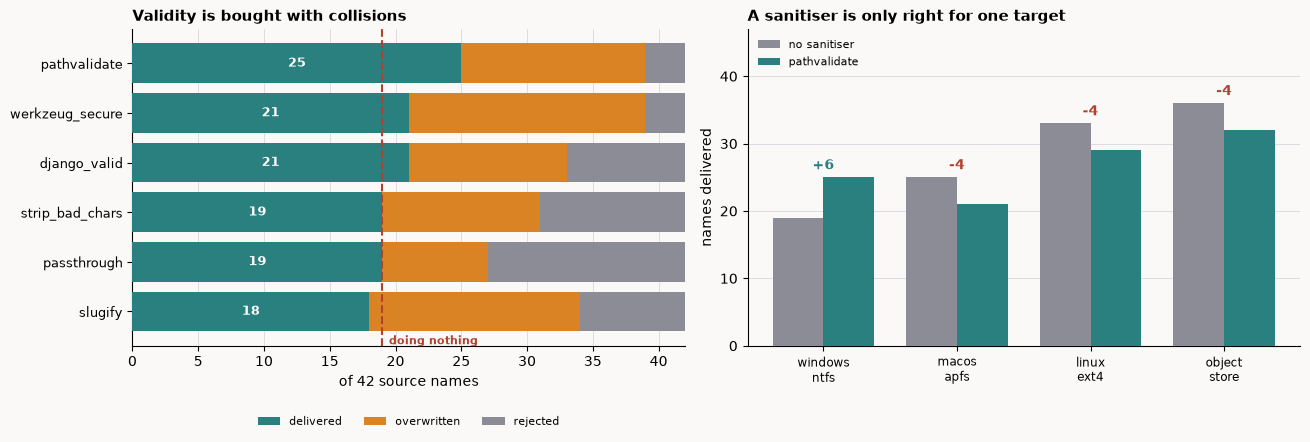

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

DELIVERED, OVERWRITTEN, REJECTED = '#2a7f7f', '#d98324', '#8c8c96'
ACCENT, PAPER = '#b3402f', '#faf9f7'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 4.6))
fig.patch.set_facecolor(PAPER)
for ax in (ax1, ax2):
    ax.set_facecolor(PAPER)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    ax.set_axisbelow(True)

order = sorted(results, key=lambda k: results[k][0])
y = range(len(order))
d = [results[k][0] for k in order]
o = [results[k][1] for k in order]
j = [results[k][2] for k in order]
ax1.barh(y, d, color=DELIVERED, label='delivered', zorder=3)
ax1.barh(y, o, left=d, color=OVERWRITTEN, label='overwritten', zorder=3)
ax1.barh(y, j, left=[a + b for a, b in zip(d, o)], color=REJECTED,
         label='rejected', zorder=3)
for i, k in enumerate(order):
    ax1.text(results[k][0] / 2, i, str(results[k][0]), va='center',
             ha='center', color='white', fontweight='bold', fontsize=9, zorder=4)
ax1.axvline(nothing, color=ACCENT, lw=1.5, ls='--', zorder=5)
ax1.text(nothing + 0.5, -0.66, 'doing nothing', color=ACCENT, fontsize=8,
         fontweight='bold')
ax1.set_yticks(list(y))
ax1.set_yticklabels(order, fontsize=9)
ax1.set_xlim(0, len(NAMES))
ax1.set_xlabel('of %d source names' % len(NAMES))
ax1.set_title('Validity is bought with collisions', loc='left',
              fontweight='bold', fontsize=11)
ax1.grid(True, axis='x', color='#dcdce2', lw=0.7, zorder=0)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.19), ncol=3,
           frameon=False, fontsize=8)

labels = [p.name for p in PROFILES]
x = range(len(labels))
w = 0.38
ax2.bar([i - w / 2 for i in x], [gains[k][0] for k in labels], w,
        color=REJECTED, label='no sanitiser', zorder=3)
ax2.bar([i + w / 2 for i in x], [gains[k][1] for k in labels], w,
        color=DELIVERED, label='pathvalidate', zorder=3)
for i, k in enumerate(labels):
    a, b = gains[k]
    ax2.annotate('%+d' % (b - a), xy=(i, max(a, b) + 1.2), ha='center',
                 fontsize=10, fontweight='bold',
                 color=DELIVERED if b > a else ACCENT)
ax2.set_xticks(list(x))
ax2.set_xticklabels([k.replace('-', '\n') for k in labels], fontsize=8.5)
ax2.set_ylim(0, len(NAMES) + 5)
ax2.set_ylabel('names delivered')
ax2.set_title('A sanitiser is only right for one target', loc='left',
              fontweight='bold', fontsize=11)
ax2.grid(True, axis='y', color='#dcdce2', lw=0.7, zorder=0)
ax2.legend(loc='upper left', frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig('sanitise_demo.png', dpi=150, facecolor=PAPER)
print('saved sanitise_demo.png')
plt.show()

## What the audit concludes

| | |
|---|---|
| **The failures that lose data are relations between names** | A collision is a fact about a *pair*. A function returning `str` has one name in scope, so it cannot report one - no matter how good its deny-list is. |
| **Doing nothing beat two of the five real sanitisers** | Not because they are badly written, but because collision count is monotone in how much a projection throws away, and `strip_bad_chars` throws away the character that distinguished four names while fixing no device name and no length. |
| **The same sanitiser was right once and wrong three times** | Positive on Windows, negative on APFS, ext4 and the object store. Sanitising runs at upload time; the target is chosen at write time. |
| **`CON.txt` is the console** | Two of six implementations knew that. |
| **`casefold()` is more destructive than NTFS** | It merges `Straße` into `STRASSE`; the volume does not. `lower()` errs the other way on Greek. Neither is a case table. |
| **255 is not a character count** | 90 CJK characters: legal on NTFS, over the limit on ext4. And truncating to fit splits code points on some inputs and not others, so it passes whichever test you wrote. |

### The three verdicts

| verdict | meaning |
|---|---|
| `portable` | every name is writable on every target, and the mapping is injective on every target |
| `lossy` | every name is writable, but two sources land on one file somewhere. The write succeeds and a file is gone. |
| `rejected` | at least one name cannot be written at all |

`portable` is a claim about whether the bytes survive the round trip. It is **not** a claim that a human can tell two files apart - `report‐2024.pdf` with U+2010 and `report-2024.pdf` with U+002D are `portable` everywhere and still indistinguishable on screen. Read the findings.

## Try your own

Uncomment and edit. Paste in a real directory listing - an export folder, an S3 prefix, a zip manifest - and pick the target you actually write to.

In [12]:
# my_names = [
#     'Q1 Report.csv',
#     'q1 report.csv',      # case pair: one file on Windows and macOS
#     'summary.',           # trailing dot: Win32 strips it
#     'summary',
#     'CON.txt',            # the console
#     'caf\u00e9.txt',
#     'cafe\u0301.txt',        # NFD: one file on APFS, two on ext4
# ]
#
# for p in PROFILES:
#     dest = 'C:\\data' if p.name.startswith('windows') else '/data'
#     d, o, j = audit(my_names, p, dest, 'pathvalidate')
#     print('%-16s delivered=%-3d overwritten=%-3d rejected=%d'
#           % (p.name, len(d), len(o), len(j)))
#     for n in o:
#         print('    overwritten:', repr(n))

# Or list every real directory you have, and see which pairs would merge:
# import os
# listing = os.listdir('.')
# for p in PROFILES:
#     d, o, j = audit(listing, p, '.', 'passthrough')
#     print(p.name, 'would merge', len(o), 'of', len(listing))

---

**Day 146 of the [FDE portfolio](https://github.com/phoebefu6/phoebe-the-builder)** · Automation Suite

The full engine - 16 finding codes across three severities, five target profiles, the collision-reason classifier, and 224 tests - is in [`sanitise.py`](sanitise.py). Every number in the README is computed by [`evidence.py`](evidence.py).

```bash
python3 -m pytest test_sanitise.py -q   # 224 tests
python3 evidence.py                     # every number in the README
python3 make_chart.py                   # the six-panel figure
streamlit run app.py                    # paste a listing, read the verdict
```